In [1]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams['text.usetex'] = True

In [2]:
post_path = '/pscratch/sd/m/mckenna/dharma_post/'

with open(post_path + 'cntl_bin_ice_sounding_time_series.pkl', 'rb') as f:
    bin_d = pickle.load(f)

with open(post_path + 'cntl_bulk_ice_ABIFM_sounding_time_series.pkl', 'rb') as f:
    bulk_d = pickle.load(f)

print('Bin  keys:', sorted(bin_d.keys()))
print('Bulk keys:', sorted(bulk_d.keys()))

Bin  keys: ['T', 'avg_T_flx', 'avg_T_sfc', 'avg_precip', 'avg_qv_flx', 'avg_ustar', 'cfl', 'clwc', 'clwp', 'iwc', 'iwc2', 'iwp', 'iwpf', 'lwc', 'lwp', 'max_in_imm', 'max_precip', 'max_qi', 'max_qif', 'max_sh_coag', 'max_sh_coag_raw', 'max_sh_in', 'max_w', 'nbigice_cld', 'nc_cld', 'nd_cld', 'net_cond', 'net_dep', 'nif_cld', 'nqc', 'nqif', 'nql', 'nqr', 'nr_cld', 'ntot_1', 'ntot_2', 'ntot_3', 'ntot_ifn', 'qc', 'qif', 'qif2', 'ql', 'qr', 'reff_2', 'reff_3', 'reff_drops', 'rhimax', 'rhmax', 'rhobar', 'rwc', 'rwp', 'time', 'tke_smag', 'wmax', 'zt', 'zw']
Bulk keys: ['T', 'avg_T_flx', 'avg_T_sfc', 'avg_precip', 'avg_qv_flx', 'avg_ustar', 'clwc', 'clwp', 'iwp', 'iwpc', 'iwpd', 'iwpf', 'lwc', 'lwp', 'max_in_imm_c', 'max_in_imm_r', 'max_precip', 'max_sh_coag', 'max_sh_coag_raw', 'max_sh_in_c', 'max_sh_in_r', 'max_w', 'na_1', 'na_2', 'na_3', 'na_tot', 'nc_cld', 'net_cond', 'net_dep', 'nic', 'nic_cld', 'nid', 'nid_cld', 'nif', 'nif_cld', 'nqc', 'nqic', 'nqid', 'nqif', 'nqitot', 'nqr', 'nr_cld', '

/tmp/ipykernel_616071/1005407645.py:50: UserWarning: Log scale: values of z <= 0 have been masked
  pm_lwc_bin   = axes[0, 1].contourf(bin_time,  bin_zt,  bin_lwc.T,   **lwc_kw)
/tmp/ipykernel_616071/1005407645.py:51: UserWarning: Log scale: values of z <= 0 have been masked
  pm_iwc_bin   = axes[0, 2].contourf(bin_time,  bin_zt,  bin_iwc.T,   **iwc_kw)
/tmp/ipykernel_616071/1005407645.py:55: UserWarning: Log scale: values of z <= 0 have been masked
  pm_lwc_bulk  = axes[1, 1].contourf(bulk_time, bulk_zt, bulk_lwc.T,  **lwc_kw)
/tmp/ipykernel_616071/1005407645.py:56: UserWarning: Log scale: values of z <= 0 have been masked
  pm_iwc_bulk  = axes[1, 2].contourf(bulk_time, bulk_zt, bulk_iwc.T,  **iwc_kw)


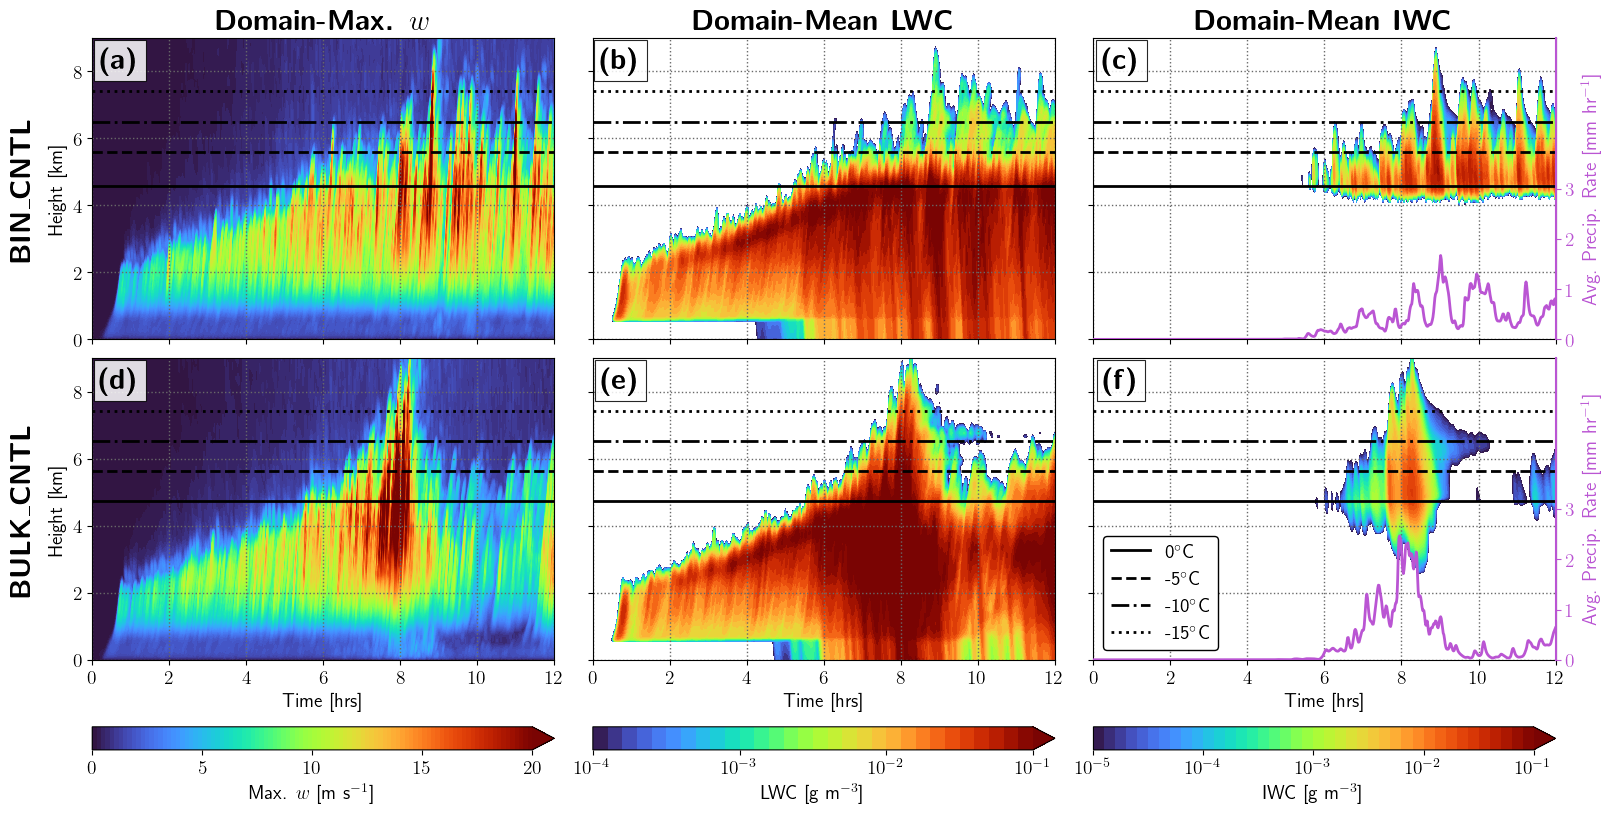

In [3]:
Fontsize = 14
props    = dict(boxstyle='square', facecolor='wheat', alpha=0.7)

# --- Unpack bin ---
bin_time = bin_d['time'] / 3600.             # s -> hours
bin_zt   = np.asarray(bin_d['zt']) * 1.e-3  # m -> km
bin_zw   = np.asarray(bin_d['zw']) * 1.e-3  # m -> km
bin_wmax = bin_d['wmax']                     # (time, z)
bin_lwc  = bin_d['lwc']                      # total liquid WC  [g m-3]
bin_iwc  = bin_d['iwc']                      # pristine ice WC  [g m-3]
bin_T    = bin_d['T']                        # (time, z)  [K]

# --- Unpack bulk (ABIFM restart merged) ---
bulk_time = bulk_d['tmp_time']               # already hours
bulk_zt   = np.asarray(bulk_d['zt']) * 1.e-3
bulk_zw   = np.asarray(bulk_d['zw']) * 1.e-3
bulk_wmax = bulk_d['wmax']
bulk_lwc  = bulk_d['lwc']                    # total liquid WC  [g m-3]
bulk_iwc  = bulk_d['qi_iwc']                 # total ice WC     [g m-3]
#bulk_iwc  = bulk_d['qic_iwc']                 # total ice WC     [g m-3]
bulk_T    = bulk_d['T']

# --- Precipitation (change precip_color here to update everything) ---
precip_color    = 'mediumorchid'
bin_avg_precip  = bin_d['avg_precip']   # mm hr-1
bulk_avg_precip = bulk_d['avg_precip']  # mm hr-1

cmap = 'turbo'

# --- Shared plot settings per column ---
wmax_levels     = np.arange(0, 20.2, 0.2)
wmax_kw         = dict(cmap=cmap, levels=wmax_levels, extend='max')
wmax_cbar_ticks = np.arange(0, 25, 5)

lwc_levels      = 10.**np.arange(-4, -0.9, 0.1)
lwc_norm        = matplotlib.colors.LogNorm(vmin=1.e-4, vmax=1.e-1)
lwc_kw          = dict(cmap=cmap, levels=lwc_levels, norm=lwc_norm, extend='max')
lwc_cbar_ticks  = 10.**np.arange(-4, 0, 1)

iwc_levels      = 10.**np.arange(-5, -0.9, 0.1)
iwc_norm        = matplotlib.colors.LogNorm(vmin=1.e-5, vmax=1.e-1)
iwc_kw          = dict(cmap=cmap, levels=iwc_levels, norm=iwc_norm, extend='max')
iwc_cbar_ticks  = 10.**np.arange(-5, 0, 1)

# --- Figure ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

# Top row: bin
pm_wmax_bin  = axes[0, 0].contourf(bin_time,  bin_zw,  bin_wmax.T,  **wmax_kw)
pm_lwc_bin   = axes[0, 1].contourf(bin_time,  bin_zt,  bin_lwc.T,   **lwc_kw)
pm_iwc_bin   = axes[0, 2].contourf(bin_time,  bin_zt,  bin_iwc.T,   **iwc_kw)

# Bottom row: bulk
pm_wmax_bulk = axes[1, 0].contourf(bulk_time, bulk_zw, bulk_wmax.T, **wmax_kw)
pm_lwc_bulk  = axes[1, 1].contourf(bulk_time, bulk_zt, bulk_lwc.T,  **lwc_kw)
pm_iwc_bulk  = axes[1, 2].contourf(bulk_time, bulk_zt, bulk_iwc.T,  **iwc_kw)

# --- Shared colorbars at bottom of each column ---
cb_wmax = fig.colorbar(pm_wmax_bulk, ax=[axes[0, 0], axes[1, 0]],
                       location='bottom', pad=0.02, ticks=wmax_cbar_ticks)
cb_lwc  = fig.colorbar(pm_lwc_bulk,  ax=[axes[0, 1], axes[1, 1]],
                       location='bottom', pad=0.02, ticks=lwc_cbar_ticks)
cb_iwc  = fig.colorbar(pm_iwc_bulk,  ax=[axes[0, 2], axes[1, 2]],
                       location='bottom', pad=0.02, ticks=iwc_cbar_ticks)

for cb, label in [(cb_wmax, 'Max. $w$ [m s$^{-1}$]'),
                  (cb_lwc,  'LWC [g m$^{-3}$]'),
                  (cb_iwc,  'IWC [g m$^{-3}$]')]:
    cb.ax.tick_params(labelsize=Fontsize)
    cb.set_label(label, fontsize=Fontsize)

# --- Axes formatting ---
row_labels  = [r'\textbf{BIN\_CNTL}', r'\textbf{BULK\_CNTL}']
panel_props = dict(boxstyle='square', facecolor='white', alpha=0.85, edgecolor='k', linewidth=0.8, pad=0.2)
panel_ids   = [r'\textbf{(a)}', r'\textbf{(b)}', r'\textbf{(c)}', r'\textbf{(d)}', r'\textbf{(e)}', r'\textbf{(f)}']

for row in range(2):
    for col in range(3):
        ax = axes[row, col]
        ax.tick_params(labelsize=Fontsize)
        ax.set_ylim(0, 9)
        ax.grid(ls='dotted', lw=1, c='dimgrey')

        # Bottom row only gets x-axis label; top row keeps tick marks but no labels
        if row == 1:
            ax.set_xlabel('Time [hrs]', fontsize=Fontsize)
        else:
            ax.tick_params(axis='x', labelbottom=False)

        # Columns 2-3: keep tick marks but remove y-axis tick labels and axis label
        if col == 0:
            ax.set_ylabel('Height [km]', fontsize=Fontsize)
        else:
            ax.tick_params(axis='y', labelleft=False)
            ax.set_ylabel('')

        # Panel labels (a)-(f)
        ax.text(0.06, 0.925, panel_ids[row * 3 + col], fontsize=Fontsize*1.5,
                fontweight='bold', c='k', transform=ax.transAxes,
                va='center', ha='center', bbox=panel_props, zorder=5)

    # Row labels as text on the leftmost panel
    axes[row, 0].text(-0.15, 0.5, row_labels[row], fontsize=Fontsize*1.5,
                      fontweight='bold', c='k', transform=axes[row, 0].transAxes,
                      va='center', ha='center', rotation=90)

# --- xlim ---
for col in range(3):
    axes[0, col].set_xlim(np.min(bin_time),  np.max(bin_time))
    axes[1, col].set_xlim(np.min(bulk_time), np.max(bulk_time))

# --- Precipitation twin y-axes (rightmost column only) ---
ax_precip_bin  = axes[0, 2].twinx()
ax_precip_bulk = axes[1, 2].twinx()
for ax_p, t, precip in [(ax_precip_bin,  bin_time,  bin_avg_precip),
                         (ax_precip_bulk, bulk_time, bulk_avg_precip)]:
    ax_p.plot(t, precip, color=precip_color, lw=2)
    ax_p.set_ylim(0,6)
    ax_p.set_yticks([0,1,2,3])
    ax_p.set_ylim(bottom=0)
    ax_p.tick_params(axis='y', colors=precip_color, labelsize=Fontsize)
    ax_p.spines['right'].set_color(precip_color)
    ax_p.spines['right'].set_linewidth(1.5)
    ax_p.spines['top'].set_visible(False)
    ax_p.spines['bottom'].set_visible(False)
    ax_p.spines['left'].set_visible(False)
    ax_p.set_xlim(t[0], t[-1])
ax_precip_bulk.set_ylabel('Avg. Precip. Rate [mm hr$^{-1}$]', color=precip_color, fontsize=Fontsize)
ax_precip_bin.set_ylabel('Avg. Precip. Rate [mm hr$^{-1}$]', color=precip_color, fontsize=Fontsize)

# --- Mean-T isotherms over last 6 hours ---
tmp_color='k'
T_levels = [(0,   tmp_color, 'solid'),
            (-5,  tmp_color, 'dashed'),
            (-10, tmp_color, '-.'),
            (-15, tmp_color, 'dotted')]
dumstr = '$^{\circ}$C'

# Mean T profile over the last 6 hours of each simulation
bin_last6   = bin_time  >= (np.max(bin_time)  - 6.)
bulk_last6  = bulk_time >= (np.max(bulk_time) - 6.)
bin_T_mean  = np.mean(bin_T[bin_last6,   :], axis=0) - 273.15   # (nz,)
bulk_T_mean = np.mean(bulk_T[bulk_last6, :], axis=0) - 273.15   # (nz,)

for level, color, ls in T_levels:
    bin_z_lev  = np.interp(level, bin_T_mean[::-1],  bin_zt[::-1])
    bulk_z_lev = np.interp(level, bulk_T_mean[::-1], bulk_zt[::-1])
    for col in range(3):
        axes[0, col].axhline(bin_z_lev,  color=color, ls=ls, lw=2)
        axes[1, col].axhline(bulk_z_lev, color=color, ls=ls, lw=2)

legend_lines  = [Line2D([0], [0], color=c, lw=2, ls=ls) for _, c, ls in T_levels]
legend_labels = [str(int(lv)) + dumstr for lv, _, _ in T_levels]
lgnd = axes[1, 2].legend(legend_lines, legend_labels, loc='lower left',
                          bbox_to_anchor=(0., 0.), fontsize=Fontsize, ncol=1,
                          framealpha=True, edgecolor='k')

axes[0, 0].set_title(r'\textbf{Domain-Max. $w$}', fontsize=Fontsize*1.5)
axes[0, 1].set_title(r'\textbf{Domain-Mean LWC}',             fontsize=Fontsize*1.5)
axes[0, 2].set_title(r'\textbf{Domain-Mean IWC}',             fontsize=Fontsize*1.5)

plt.show()